# 03_01 - XGBoost Classifier: Peak-Risk Training and Evaluation

The second model of the project: a pooled, row-wise XGBoost classifier that predicts whether a given hour will be a demand peak, evaluated on the same 3 expanding-window folds as the regressor. Unlike the regressor, the peak threshold itself is fold-dependent - it comes only from that fold's own training years - so labeling happens per fold here rather than once for the whole dataset.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parents[1] / "src"))

import pandas as pd
import matplotlib.pyplot as plt
from common.folds import FOLDS, split_fold
from common.labeling import compute_peak_thresholds
from common.metrics import peak_risk_metrics, top_k_capture_rate, calibration_data
from peak_risk.XGBoost_Classifier import build_training_table, train_and_predict

DATA_PATH = Path.cwd().parents[1] / "data" / "interim" / "fsa_hourly_master.parquet"
df = pd.read_parquet(DATA_PATH)

table = build_training_table(df)
print("training table shape:", table.shape)

training table shape: (6307200, 23)


## 1. Train and evaluate on all 3 folds

Each fold needs two separate splits of the same source data. The peak threshold (97.5th percentile of consumption per FSA/season) has to come from that fold's raw hourly rows, `compute_peak_thresholds()` run directly on the train years of `df`, before any pivoting. Computing it from the pivoted `table` instead would be wrong: a real hour repeats there once for every horizon that reaches it, and while that repetition is close to uniform across most hours, it is not exact at the edges of the training window, so the raw hourly source is the only unambiguous choice. The features and `horizon` column that go into the model come from `table`, split the same way by year.

`train_and_predict()` labels both splits with the fold's own thresholds, fits one `XGBClassifier` on the training years, and returns predictions on the test year already in the required schema (plus `horizon` as an extra column, kept because a single `forecast_timestamp` gets one prediction per horizon that reaches it, the required 6 columns do not distinguish those rows on their own).

In [2]:
fold_results = {}
for fold_name in FOLDS:
    raw_train, _ = split_fold(df, fold_name)
    train_table, test_table = split_fold(table, fold_name)
    thresholds = compute_peak_thresholds(raw_train)
    fold_results[fold_name] = train_and_predict(train_table, test_table, thresholds)
    actual_rate = fold_results[fold_name]["actual_peak"].mean()
    print(f"{fold_name} done - {len(fold_results[fold_name])} rows, actual peak rate {actual_rate:.2%}")

fold_1 done - 1261440 rows, actual peak rate 10.96%


fold_2 done - 1264896 rows, actual peak rate 4.00%


fold_3 done - 1257984 rows, actual peak rate 6.92%


The actual peak rate above matches what the labeling module already showed on its own earlier: around 11% for fold_1 (test 2023), 4% for fold_2 (test 2024), 7% for fold_3 (test 2025), never the nominal 2.5% the threshold is built from, because that threshold is fixed from older, generally lower-consumption training years while consumption keeps rising, so more test hours end up clearing an increasingly outdated bar.

## 2. Overall metrics per fold

PR-AUC is the primary metric here, not accuracy or even ROC-AUC, since peaks are a small minority class and both of those can look good while missing most of them.

In [3]:
summary = pd.DataFrame({
    fold_name: peak_risk_metrics(results["actual_peak"], results["peak_probability"], results["predicted_peak"])
    for fold_name, results in fold_results.items()
}).T
summary

,pr_auc,precision,recall,f1,roc_auc,brier
fold_1,0.439747,0.546304,0.334633,0.415038,0.794515,0.085326
fold_2,0.583438,0.338958,0.845478,0.483913,0.961601,0.051472
fold_3,0.584514,0.435687,0.747266,0.550443,0.943033,0.059806


A useful baseline for PR-AUC is the base peak rate itself, roughly what a classifier with no real skill would score, since it would just be ranking positives at random among everything. Against that baseline (about 0.11 for fold_1, 0.04 for fold_2, 0.07 for fold_3), all 3 folds land well above chance: 0.44, 0.58, 0.58.

fold_1 is clearly the weakest of the three on PR-AUC, the same pattern already seen with the regressor, it only has 2021-2022 to train on, half the years fold_3 gets. fold_2 and fold_3 land close to each other on PR-AUC (0.58 both) despite very different base rates (4% vs 7%), which is one of the reasons PR-AUC is preferred over recall or precision alone here, those two swing a lot more with the base rate on their own (recall 0.85 vs 0.75, precision 0.34 vs 0.44) even though the underlying ranking quality is about the same.

### Predicted vs. actual peak rate

The 0.5 probability threshold used for `predicted_peak` is a first-pass default, not something tuned against `scale_pos_weight` - worth checking directly whether it over- or under-flags peaks in each fold before trusting precision/recall at face value.

In [4]:
rate_comparison = pd.DataFrame({
    fold_name: {
        "actual_peak_rate": results["actual_peak"].mean(),
        "predicted_peak_rate": results["predicted_peak"].mean(),
    }
    for fold_name, results in fold_results.items()
}).T
rate_comparison

,actual_peak_rate,predicted_peak_rate
fold_1,0.109592,0.067130
fold_2,0.040025,0.099835
fold_3,0.069196,0.118682


The 3 folds do not behave the same way at the 0.5 threshold. fold_1 under-flags (6.7% predicted vs 11.0% actual), while fold_2 and fold_3 both over-flag, and by a larger relative margin (10.0% vs 4.0%, 11.9% vs 6.9%).

Two different things are likely mixed together here, and it is worth being honest that this notebook does not fully separate them yet. `scale_pos_weight` is computed from each fold's train split, but the peak threshold is always the 97.5th percentile of that same train split, so train's own positive rate is pinned to about 2.5% by construction in all 3 folds, and `scale_pos_weight` comes out close to 39 regardless of fold. It has no way to know how far the test year's real prevalence has drifted from that 2.5% baseline (11.0%, 4.0%, 6.9%, all different), so a fixed correction tuned for one assumed imbalance cannot be exactly right for all three. This is a plausible partial explanation for fold_2 and fold_3 over-flagging. It does not obviously explain fold_1 under-flagging on its own, though, fold_1 is also the fold with by far the weakest PR-AUC (0.44), so its predicted probabilities are probably just less separated overall from having the least training data, which would push more of them below 0.5 regardless of `scale_pos_weight`. Untangling these properly would need testing different threshold or reweighting choices directly, which is future work, not something resolved here.

## 3. Ranking quality by horizon

Same question already asked of the regressor: the model is checked for whether it gets worse the further out it is asked to look. `horizon` is a feature here, not something structural like the regressor's 24 output columns, so this checks whether it actually helps the model or just adds a dimension it ignores.

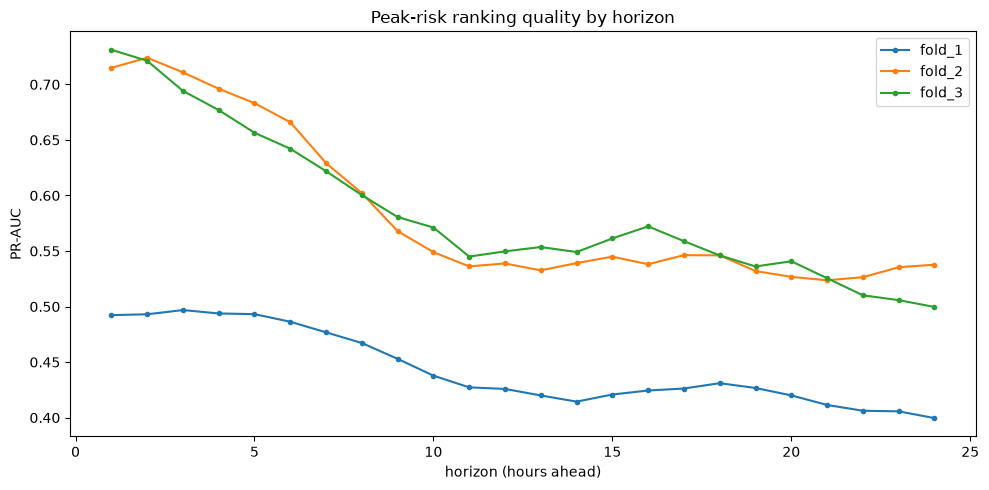

In [5]:
by_horizon = {}
for fold_name, results in fold_results.items():
    rows = []
    for horizon, group in results.groupby("horizon"):
        row = peak_risk_metrics(group["actual_peak"], group["peak_probability"], group["predicted_peak"])
        row["horizon"] = horizon
        rows.append(row)
    by_horizon[fold_name] = pd.DataFrame(rows).set_index("horizon").sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
for fold_name, metrics_df in by_horizon.items():
    ax.plot(metrics_df.index, metrics_df["pr_auc"], marker="o", markersize=3, label=fold_name)
ax.set_xlabel("horizon (hours ahead)")
ax.set_ylabel("PR-AUC")
ax.set_title("Peak-risk ranking quality by horizon")
ax.legend()
fig.tight_layout()
plt.show()

In [6]:
pd.DataFrame({
    fold_name: {"pr_auc_h1": metrics_df.loc[1, "pr_auc"], "pr_auc_h12": metrics_df.loc[12, "pr_auc"], "pr_auc_h24": metrics_df.loc[24, "pr_auc"]}
    for fold_name, metrics_df in by_horizon.items()
}).T

,pr_auc_h1,pr_auc_h12,pr_auc_h24
fold_1,0.492282,0.425871,0.399616
fold_2,0.714833,0.538824,0.537708
fold_3,0.731207,0.549705,0.499655


PR-AUC drops with horizon in fold_1 and fold_3 (0.49 to 0.40, 0.73 to 0.50), the same degrading-with-distance pattern already seen in the regressor's WAPE-by-horizon. fold_2 drops sharply from h1 to h12 (0.71 to 0.54) but is nearly flat from h12 to h24 (0.54 to 0.54), not a contradiction of the pattern, just evidence most of the loss happens early and levels off in that particular fold.

Recall by horizon (not shown in the plot above) tells a different part of the story: it barely moves across horizons within a fold, for example fold_3 goes from 0.82 recall at h1 to 0.68 at h24, a much smaller relative drop than PR-AUC's. That split matters: PR-AUC measures how well the model *ranks* hours by risk, while recall at the fixed 0.5 threshold measures a specific decision. The ranking quality erodes with horizon more than the fixed-threshold decision does, which is a reason to keep `horizon` in the feature set even though its effect is not visible everywhere.

## 4. Calibration

PR-AUC and recall only care about ranking and about a threshold decision, neither checks whether `peak_probability` means what it says. If the model outputs 0.8, the hour should turn out to be a peak roughly 80% of the time for that probability to be trustworthy. Checked on fold_3, since it is the most recent and most representative of the three (fold_1 is data-starved, fold_2 has the smallest base rate).

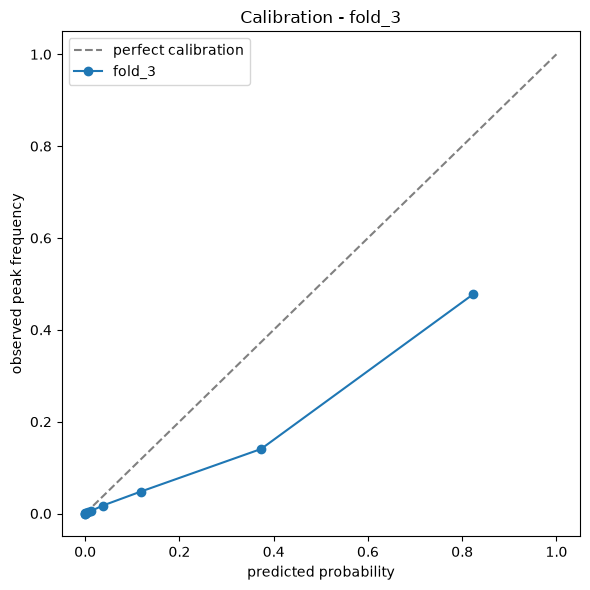

,predicted_probability,observed_frequency
0,0.000030,0.000000
1,0.000193,0.000000
2,0.000679,0.000119
3,0.001953,0.000819
4,0.005116,0.002377
5,0.013344,0.006010
6,0.037496,0.017393
7,0.117511,0.047624
8,0.373177,0.140527
9,0.822799,0.477094


In [7]:
cal = calibration_data(fold_results["fold_3"]["actual_peak"], fold_results["fold_3"]["peak_probability"])

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="perfect calibration")
ax.plot(cal["predicted_probability"], cal["observed_frequency"], marker="o", label="fold_3")
ax.set_xlabel("predicted probability")
ax.set_ylabel("observed peak frequency")
ax.set_title("Calibration - fold_3")
ax.legend()
fig.tight_layout()
plt.show()

cal

The model is overconfident across the board, and increasingly so at the high end: in the top bin, predicted probability averages 0.82 but the observed peak frequency is only 0.48, hours the model is "80% sure" about are actually peaks less than half the time. This is not a surprise given `scale_pos_weight`: it is specifically designed to push the model toward flagging the minority class more aggressively, which helps ranking and recall (both look reasonable above) at the direct cost of the output no longer being a calibrated probability. That tradeoff is why PR-AUC, not Brier score, is the primary metric the team settled on, Brier is still reported and still useful as a secondary check, but a classifier tuned this way is not expected to win on it.

## 5. Top-K capture rate

This checks the share of real peaks that would be caught if an operations team could only act on a limited number of the riskiest hours, ranked by `peak_probability`. A few realistic operational sizes are checked on fold_3, which has 87,048 actual peak-hours out of 1,257,984 test rows (6.9%).

In [8]:
r3 = fold_results["fold_3"]
n = len(r3)
top_k = pd.DataFrame({
    "top_1pct": {"k": int(n * 0.01), "capture_rate": top_k_capture_rate(r3["actual_peak"], r3["peak_probability"], int(n * 0.01))},
    "top_5pct": {"k": int(n * 0.05), "capture_rate": top_k_capture_rate(r3["actual_peak"], r3["peak_probability"], int(n * 0.05))},
    "top_10pct": {"k": int(n * 0.10), "capture_rate": top_k_capture_rate(r3["actual_peak"], r3["peak_probability"], int(n * 0.10))},
}).T
top_k

,k,capture_rate
top_1pct,12579.0,0.120899
top_5pct,62899.0,0.450820
top_10pct,125798.0,0.689470


Watching only the riskiest 1% of hours catches about 12% of real peaks, 5% catches about 45%, and 10% catches about 69%. This is a meaningfully better return than acting on a random 1/5/10% of hours would give (which would catch roughly 1%, 5%, 10% of peaks respectively, matching the base rate), the ranking is doing real work, even if it is far from perfect. Whether 10% of hours is a realistic operational budget is a business question outside the scope of this notebook, not a modeling one.

## 6. Output schema check

Confirming the required columns are present and correctly named: `FSA, forecast_timestamp, actual_peak, peak_probability, predicted_peak, model_name` (plus `horizon`, the one extra column kept for the diagnostics above).

In [9]:
fold_results["fold_3"].head()

,FSA,forecast_timestamp,actual_peak,peak_probability,predicted_peak,model_name,horizon
0,L4T,2025-01-01 01:00:00,0,0.000075,0,xgboost_classifier,1
1,L4T,2025-01-01 02:00:00,0,0.000139,0,xgboost_classifier,1
2,L4T,2025-01-01 03:00:00,0,0.000198,0,xgboost_classifier,1
3,L4T,2025-01-01 04:00:00,0,0.000189,0,xgboost_classifier,1
4,L4T,2025-01-01 05:00:00,0,0.000354,0,xgboost_classifier,1
